# Student Name: Isaiah Andres
# Student Number: C00286361

## Introduction:
In this notebook, a logistic regression model will be used to predict the likelihood of a student's academic performance being affected by their average daily hours on social media, their average sleep hours per night. The data set used will be Students' Social Media Addiction (https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships) dataset which is a survey in which students from countries around the world, such as Bangladesh, India, USA, UK, Canada, Australia, Germany, Brazil, Japan, South Korea to find information about them such as their Academic level, Country, Average Daily Hours Spent, Most Used Platform, Sleep Hours Per Night etc. 

## Questions:
Through the selected columns of the data set, questions that may be answered through the model's predictions could be:
##### How much influence does a student's average daily hours on social media have on the chances that their academic performance is affected?
##### How much influence does a student's average hours of sleep have on the chance that their academic performance is affected?

## Setting Up The data
Below the necessary imports for this dataset is made and the data set is read

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('StudentsSocialMediaAddiction.csv').dropna()

## Predictions On The Likelihood Academic Performance Being Affected Based On Average Daily Usage Hours
The in the cell below splits the data frames Avg_Daily_Usage_Hours and Affects_Academic_Performance into training and testing sets. This is so the model can be evaluated immediately and it's predictions can be seen as there's no reason to plot out any data for a logistic regression model.

In [33]:
# Features and target
X = df[['Avg_Daily_Usage_Hours']] 
y = df['Affects_Academic_Performance']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

# Fit logistic regression
logreg = LogisticRegression(random_state=16)
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)

coef = logreg.coef_[0][0]
oddsratio = np.exp(coef)

print("Mean Radius Coefficient:", coef)
print("Odds Ratio:", oddsratio)

Mean Radius Coefficient: 2.356704881506406
Odds Ratio: 10.556110446584198


## Interpreting Results
The coefficient for the mean radius of the model is 2.36 if rounded to 2 decimal places. This implies that for every increase in hours for the average daily hours spent on social media, the chances that a student's academic performance is affected goes up by 2.36%. However the odds ratio shows, that for each additional hour in the average time spent on social media, the odds of a student's academic performance being affected increases by 10 times.

## Evaluating The Model
The code below sets up the confusion matrix, to show the correct and incorrect predictions made by the model, the ROC curve which shows the effectiveness of the model and the classification report which shows the precision, recall, f1 score and how many of each classification has showed up to also show further details of the model's effectiveness.

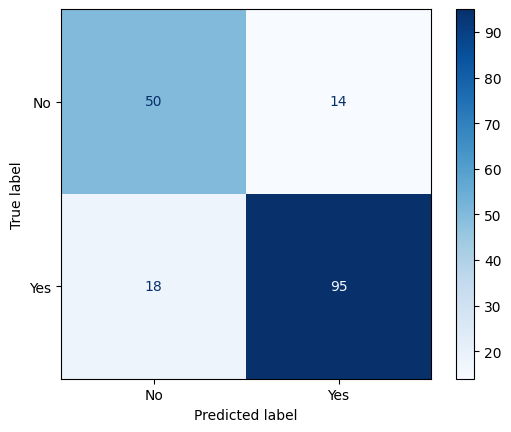

In [34]:
# Confusion matrix
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
cm_display.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=0)
plt.show()

## Confusion Matrix  
The above confusion matrix shows that the model is quite accurate, being correct 145/177 times in it's predictions. 

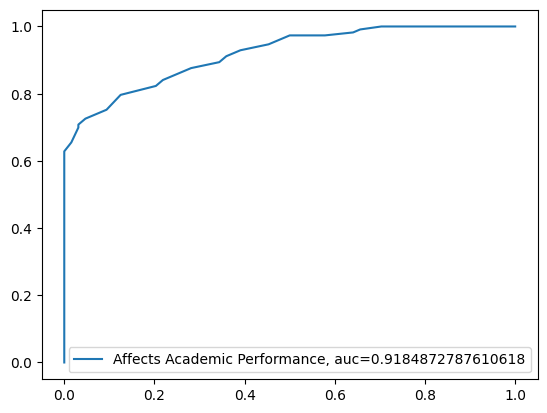

In [35]:

#ROC Curve
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba, pos_label='Yes') #Setting positive label to yes so the ROC curve can distinguish between positive and negative
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="Affects Academic Performance, auc="+str(auc))
plt.legend(loc=4)
plt.show()

## ROC Curve
The Area Under Curve (AUC) appears to be quite high as it achieved 0.918 making it quite accurate at knowing whether or not a student's academic performance is affected based on their average time spent on social media. 

In [36]:
report = classification_report(y_test, y_pred, labels=classes)
print(report)

              precision    recall  f1-score   support

          No       0.74      0.78      0.76        64
         Yes       0.87      0.84      0.86       113

    accuracy                           0.82       177
   macro avg       0.80      0.81      0.81       177
weighted avg       0.82      0.82      0.82       177



## Classification Report
The classification report generated shows that there is a high precision and recall for when the model predicts that the average hours spent on social media will affect academic performance, it has a precision of 0.87 and a recall of 0.84 and the f1 score, a mix of both the accuracy and recall also seems to be good at 0.86. When predicting if the given average number of hours spent on social media for a student doesn't affect their academic performance, it has a precision of 0.74 and a recall of 0.78, and an f1 score of 0.76. This implies that the model has a a harder time predicting if the average hours spent on social media would not affect their academic performance.

## Predictions On Likelihood of Academic Performance Being Affected Based On Average Sleep Hours Per Night
The following code uses similar code on the above prediction however with the average sleep hours per nighh as a feature set rather average time spent on social media.

In [37]:
# Features and target
X = df[['Sleep_Hours_Per_Night']] 
y = df['Affects_Academic_Performance']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

# Fit logistic regression
logreg = LogisticRegression(random_state=16)
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)

coef = logreg.coef_[0][0]
oddsratio = np.exp(coef)

print("Mean Radius Coefficient:", coef)
print("Odds Ratio:", oddsratio)

Mean Radius Coefficient: -2.0525678109040646
Odds Ratio: 0.1284047607522282


## Interpreting The Results
The coefficient for the mean radius of the model is -2.05 if rounded to 2 decimal places. This implies that for every increase in hours for the average hours spent sleeping per night, the chances that a student's academic performance is affected goes down by 2.05%. The odds ratio of 0.13 if rounded to 2 decimal places shows, that for each additional hour in the average hours spent sleeping per night, the odds of a student's academic performance being affected is lessened since the odds ratio is less than one.

## Evaluating The Model
The code below sets up the confusion matrix, ROC curve and classification report for the model, similarly to the previous evaluation with the predictions based on the likeliness of the average hours spent on social media on a student's academic performance.

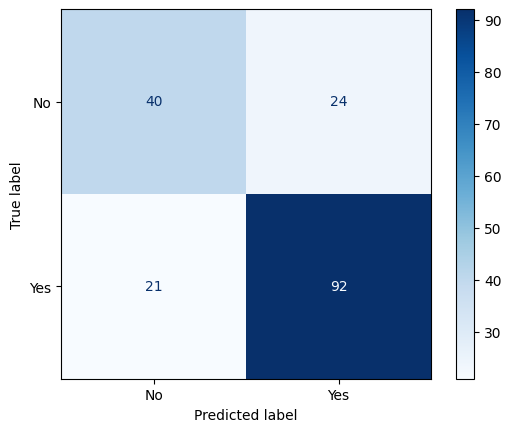

In [38]:
# Confusion matrix
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
cm_display.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=0)
plt.show()

## Confusion Matrix
The above confusion matrix shows that the model is quite accurate, being correct 132/177 times in it's predictions. The Area Under Curve (AUC) appears to be a bit worse in comparison to the previous model but still performs quite well given the AUC is 0.85.

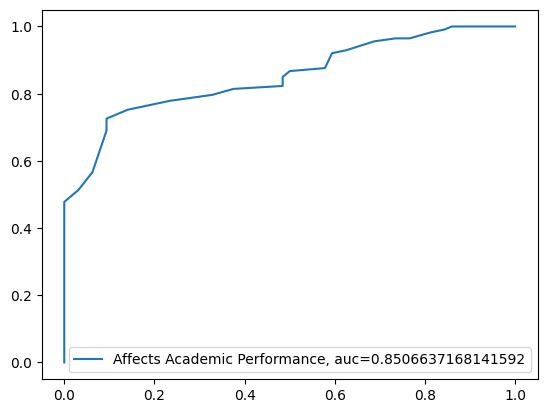

In [39]:
#ROC Curve
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba, pos_label='Yes')
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="Affects Academic Performance, auc="+str(auc))
plt.legend(loc=4)
plt.show()

## ROC Curve
The Area Under Curve (AUC) appears to be a bit worse in comparison to the previous model but still performs quite well given the AUC is 0.85.

In [40]:
report = classification_report(y_test, y_pred, labels=classes)
print(report)

              precision    recall  f1-score   support

          No       0.66      0.62      0.64        64
         Yes       0.79      0.81      0.80       113

    accuracy                           0.75       177
   macro avg       0.72      0.72      0.72       177
weighted avg       0.74      0.75      0.74       177



## Classification Report
The classification report generated above shows that there is a decent precision and recall for when the model predicts that the average hours sleeping per night will affect academic performance, as it has a precision of 0.79 and a recall of 0.81 and the f1 score, also seems to be good at 0.80. When predicting if the given average number of hours sleeping per night for a student doesn't affect their academic performance, it has a precision of 0.66 and a recall of 0.63, and an f1 score of 0.64. This implies that the model has a a harder time predicting if the average hours a student spends sleeping per night would not affect their academic performance. Overall when predicting whether a student's academic performance is affected based on average number of sleeping per night, the model seems to be less accurate in comparison to predicting based on average number of hours spent on social media.

## Conclusion
In conclusion, it appears that high amounts of social media usage can badly affect a student's academic performance and that increasing the average number of hours spent by one each time can drastically increase the odds of one's academic performance being affected negatively. The model's predictions also seem to be very accurate for that predictor given that the AUC ended up being 0.92 if rounded to 2 decimal places.

The model also suggests that the higher number of hours of sleep per night, the lower the chance of a student's academic performance being affected negatively and the odds ratio being lower than 1 at 0.13 if rounded to 2 decimal places, shows that the odds of a student's academic performance being affected is lessened, since the odds ratio is less than one. The accuracy of this model also proves ot be very good given that the AUC is 0.85 if rounded to two decimal place.